In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

In [57]:
figures_dir = Path('figures')
results_dir = Path('results')

In [58]:
results_df = pd.read_csv(results_dir / 'forecast_results.csv')
results_df['week_ending'] = pd.to_datetime(results_df['week_ending'])
history_df = pd.read_csv(results_dir / 'training_history.csv')
history_df['week_ending'] = pd.to_datetime(history_df['week_ending'])
print(f"Loaded {len(results_df)} prediction weeks and {len(history_df)} historical weeks.")

Loaded 49 prediction weeks and 126 historical weeks.


In [59]:
results_df['residual'] = results_df['predicted'] - results_df['actual']
results_df['abs_error'] = results_df['residual'].abs()
results_df['sq_error'] = results_df['residual'] ** 2

mae = results_df['abs_error'].mean()
rmse = np.sqrt(results_df['sq_error'].mean())
me = results_df['residual'].mean()
maape = np.mean(np.arctan(np.abs((results_df['actual'] - results_df['predicted']) / (results_df['actual'] + 1e-10)))) * (180/np.pi)

print(f"\n--- Metrics Summary ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Bias: {me:.2f}")
print(f"MAAPE: {maape:.2f}%")


--- Metrics Summary ---
MAE:  11.31
RMSE: 19.91
Bias: -1.71
MAAPE: 19.91%


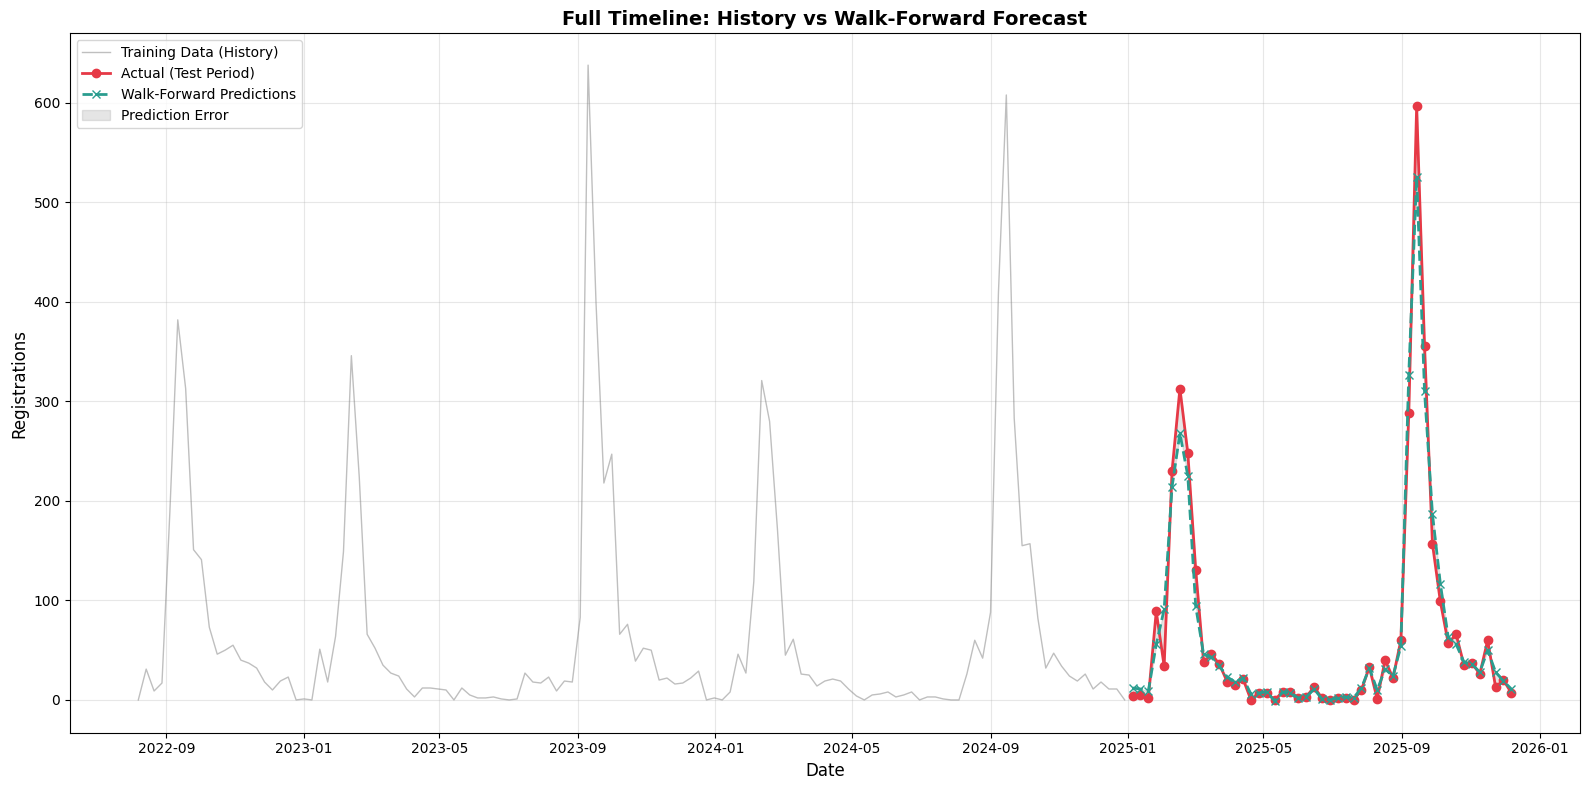

In [60]:
fig, ax = plt.subplots(figsize=(16, 8))

# Plot History
ax.plot(history_df['week_ending'], history_df['registrations'], 
        label='Training Data (History)', color='grey', alpha=0.5, linewidth=1)

# Plot Actuals (Test Period)
ax.plot(results_df['week_ending'], results_df['actual'], 
        label='Actual (Test Period)', color='#E63946', linewidth=2, marker='o', markersize=6)

# Plot Predictions
ax.plot(results_df['week_ending'], results_df['predicted'], 
        label='Walk-Forward Predictions', color='#2A9D8F', linewidth=2, 
        linestyle='--', marker='x', markersize=6)

# Fill Error
ax.fill_between(results_df['week_ending'], 
                results_df['actual'], results_df['predicted'],
                alpha=0.2, color='gray', label='Prediction Error')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Registrations', fontsize=12)
ax.set_title('Full Timeline: History vs Walk-Forward Forecast', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / '1_full_timeline.png', dpi=300)
plt.show()

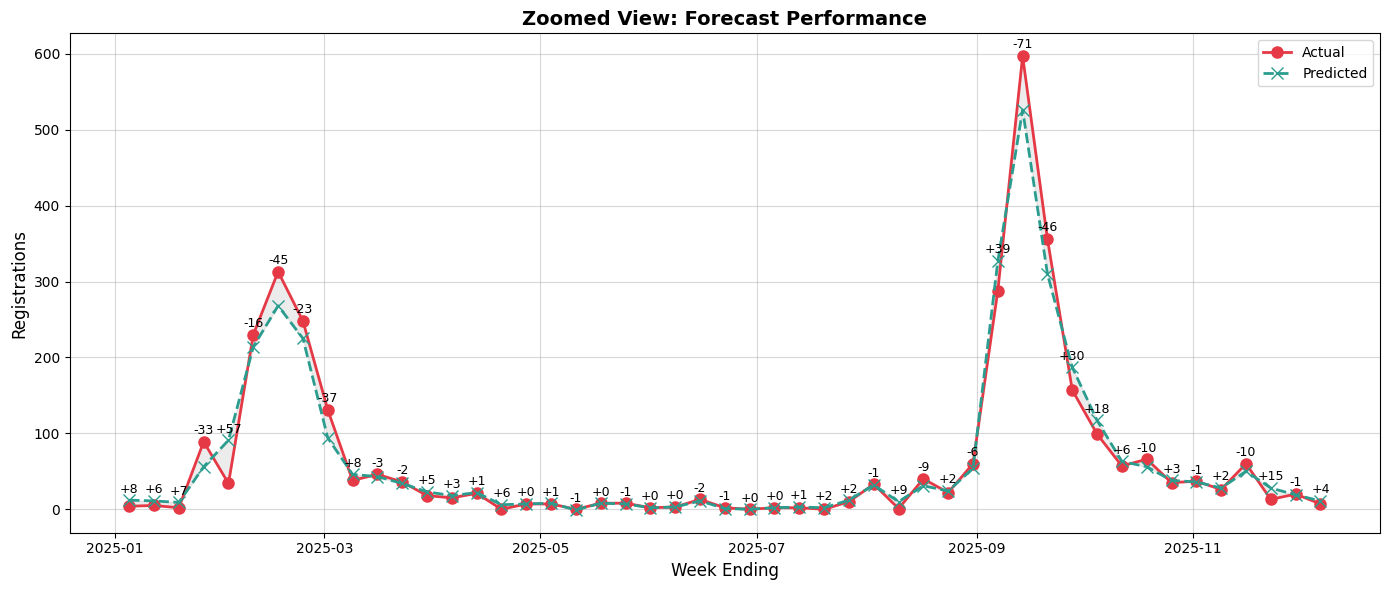

In [61]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(results_df['week_ending'], results_df['actual'], 
        label='Actual', color='#E63946', marker='o', linewidth=2, markersize=8)
ax.plot(results_df['week_ending'], results_df['predicted'], 
        label='Predicted', color='#2A9D8F', linestyle='--', marker='x', linewidth=2, markersize=8)

for idx, row in results_df.iterrows():
    error = row['predicted'] - row['actual']
    ax.annotate(f'{error:+.0f}', 
                xy=(row['week_ending'], max(row['actual'], row['predicted']) + 10),
                ha='center', fontsize=9, color='black')

ax.fill_between(results_df['week_ending'], 
                results_df['actual'], results_df['predicted'],
                alpha=0.15, color='gray')

ax.set_xlabel('Week Ending', fontsize=12)
ax.set_ylabel('Registrations', fontsize=12)
ax.set_title('Zoomed View: Forecast Performance', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig(figures_dir / '2_zoomed_forecast.png', dpi=300)
plt.show()

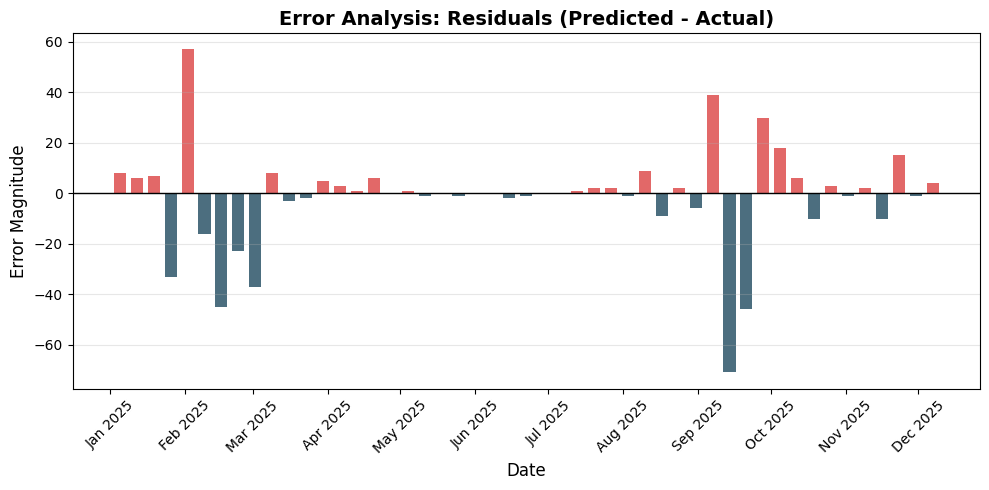

In [62]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#d62828' if x > 0 else '#003049' for x in results_df['residual']]

ax.bar(results_df['week_ending'], results_df['residual'], color=colors, alpha=0.7, width=5)
ax.axhline(0, color='black', linewidth=1, linestyle='-')

ax.set_title('Error Analysis: Residuals (Predicted - Actual)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Error Magnitude', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(figures_dir / '3_residuals.png', dpi=300)
plt.show()

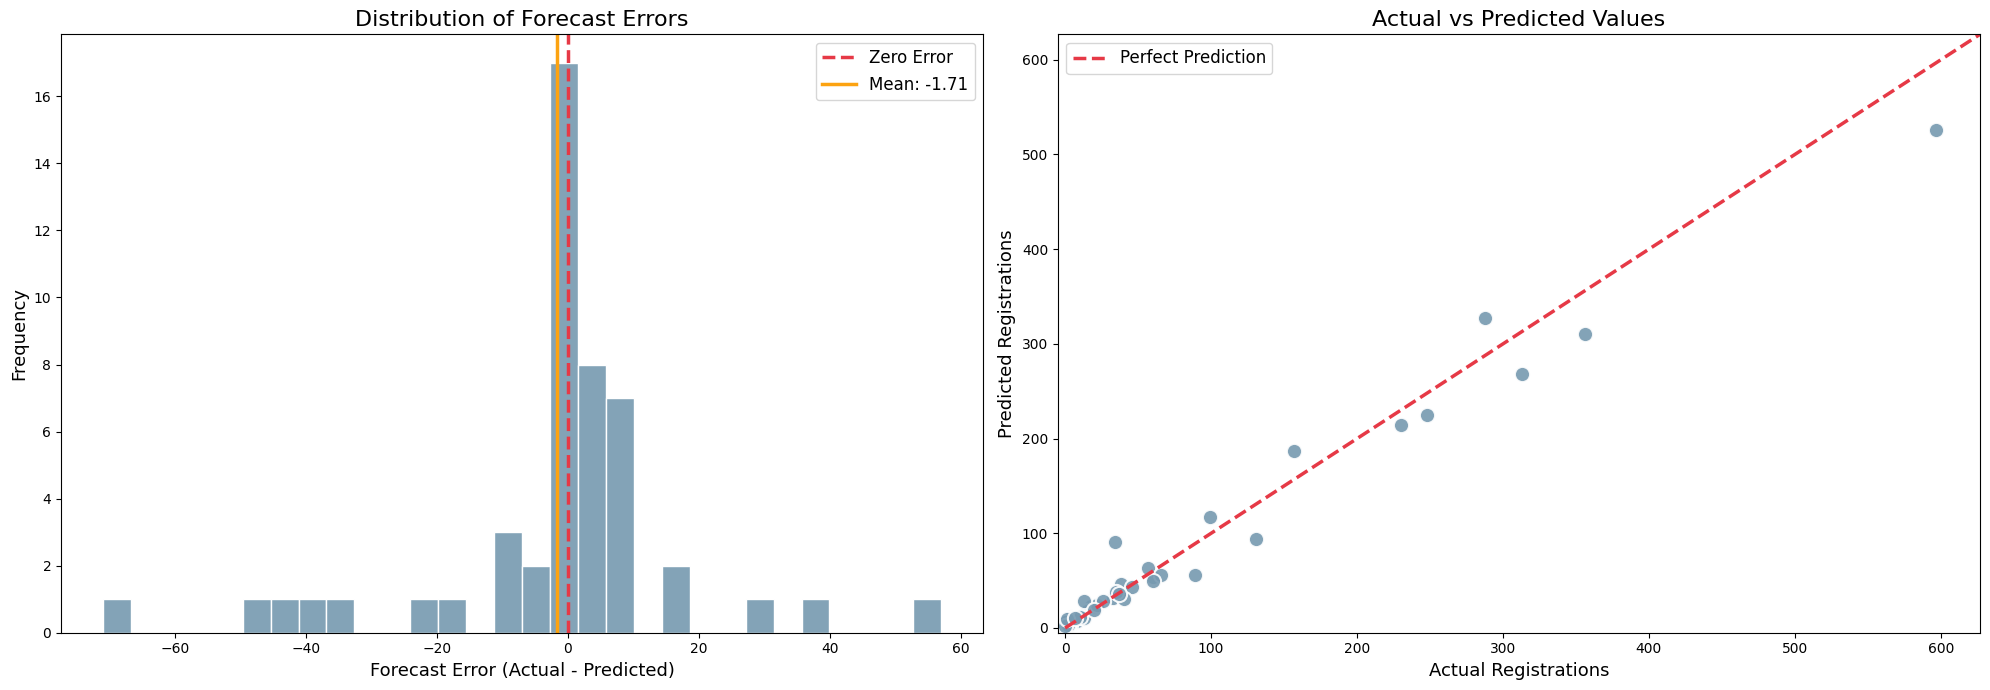

In [63]:
results_df['forecast_error'] = results_df['predicted'] - results_df['actual']
mean_error = results_df['forecast_error'].mean()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- LEFT PLOT: Distribution of Forecast Errors ---
sns.histplot(results_df['forecast_error'], ax=axes[0], 
             color='#7699b0',
             edgecolor='white',
             bins=30,
             alpha=0.9)

axes[0].axvline(0, color='#e63946', linestyle='--', linewidth=2.5, label='Zero Error')

axes[0].axvline(mean_error, color='#fca311', linestyle='-', linewidth=2.5, 
                label=f'Mean: {mean_error:.2f}')

axes[0].set_title('Distribution of Forecast Errors', fontsize=16)
axes[0].set_xlabel('Forecast Error (Actual - Predicted)', fontsize=13)
axes[0].set_ylabel('Frequency', fontsize=13)
axes[0].legend(fontsize=12)


# --- RIGHT PLOT: Actual vs Predicted ---
sns.scatterplot(data=results_df, x='actual', y='predicted', ax=axes[1],
                color='#7699b0',
                s=120,
                edgecolor='white',
                linewidth=1.5,
                alpha=0.9)

limit = max(results_df['actual'].max(), results_df['predicted'].max()) * 1.05
axes[1].plot([0, limit], [0, limit], 
             color='#e63946', linestyle='--', linewidth=2.5, 
             label='Perfect Prediction')

axes[1].set_title('Actual vs Predicted Values', fontsize=16)
axes[1].set_xlabel('Actual Registrations', fontsize=13)
axes[1].set_ylabel('Predicted Registrations', fontsize=13)
axes[1].set_xlim(-5, limit)
axes[1].set_ylim(-5, limit)
axes[1].legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig(figures_dir / '4_diagnostic_plots.png', dpi=300)
plt.show()